ARTI308 - Machine Learning

# Linear Regression with Gym Member Exercise Tracking

In this lab, we will build a linear regression model using the **gym_members_exercise_tracking.csv** dataset.

The goal is to predict **Calories_Burned** for gym members based on workout and body-measurement features such as age, weight, heart rate, workout duration, workout frequency, experience level, and workout type.

The dataset contains the following columns:

* `Age`: member age
* `Gender`: member gender
* `Weight (kg)`: member weight in kilograms
* `Height (m)`: member height in meters
* `Max_BPM`: maximum heart rate during exercise
* `Avg_BPM`: average heart rate during exercise
* `Resting_BPM`: resting heart rate
* `Session_Duration (hours)`: workout session length
* `Calories_Burned`: calories burned during the session (target variable)
* `Workout_Type`: type of workout
* `Fat_Percentage`: body fat percentage
* `Water_Intake (liters)`: daily water intake
* `Workout_Frequency (days/week)`: weekly workout frequency
* `Experience_Level`: member experience level
* `BMI`: body mass index


**Let's get started!**

## Check out the data

First, we import the libraries we need and load the gym dataset.

### Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Check out the Data

In [2]:
gym = pd.read_csv('gym_members_exercise_tracking.csv')

In [3]:
gym.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [4]:
gym.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [5]:
gym.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


In [6]:
gym.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI'],
      dtype='object')

## Basic Data Cleaning

Before modeling, we check for missing values and duplicate rows. The model can only use numeric inputs, so categorical variables will be encoded later.

In [7]:
print('Missing values per column:')
print(gym.isnull().sum())

print('\nNumber of duplicate rows:', gym.duplicated().sum())

Missing values per column:
Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

Number of duplicate rows: 0


In [8]:
gym = gym.drop_duplicates().copy()

# EDA

Let's create some simple plots to better understand the gym dataset.

Text(0.5, 1.02, 'Scatter Matrix for Selected Gym Features')

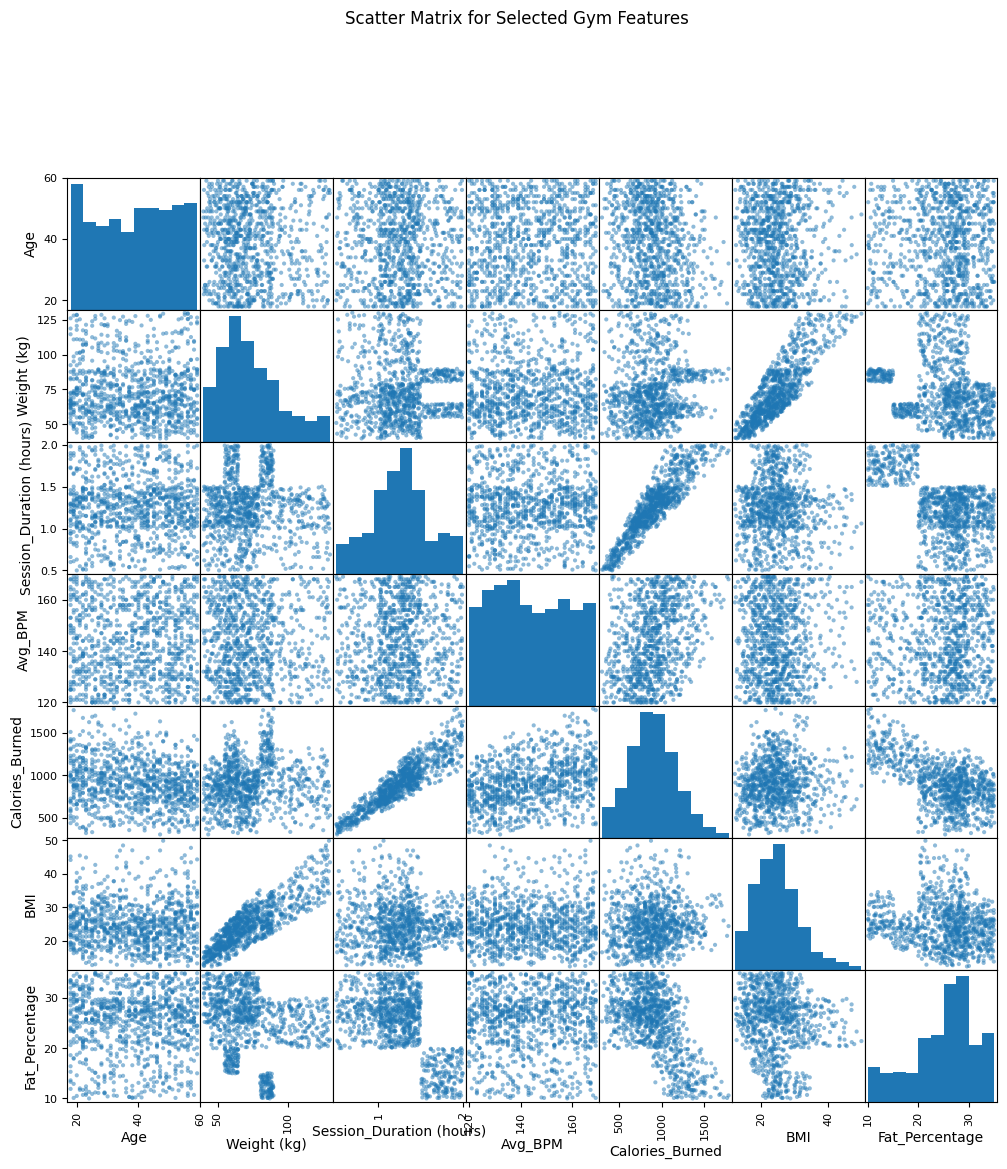

In [9]:
selected_columns = [
    'Age', 'Weight (kg)', 'Session_Duration (hours)',
    'Avg_BPM', 'Calories_Burned', 'BMI', 'Fat_Percentage'
]
pd.plotting.scatter_matrix(gym[selected_columns], figsize=(12, 12), diagonal='hist')
plt.suptitle('Scatter Matrix for Selected Gym Features', y=1.02)

Text(0, 0.5, 'Frequency')

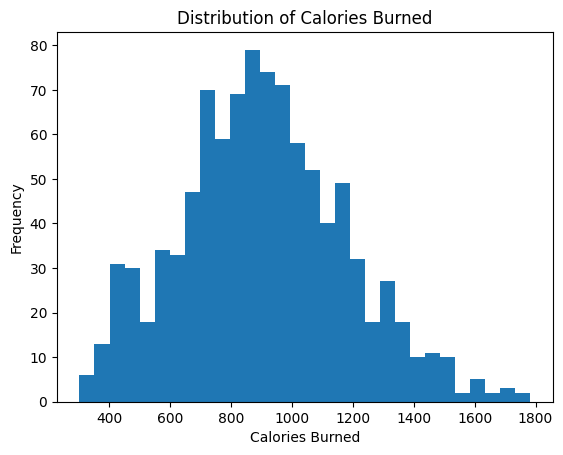

In [10]:
plt.hist(gym['Calories_Burned'], bins=30)
plt.title('Distribution of Calories Burned')
plt.xlabel('Calories Burned')
plt.ylabel('Frequency')

Text(0.5, 1.0, 'Correlation Heatmap for Numeric Features')

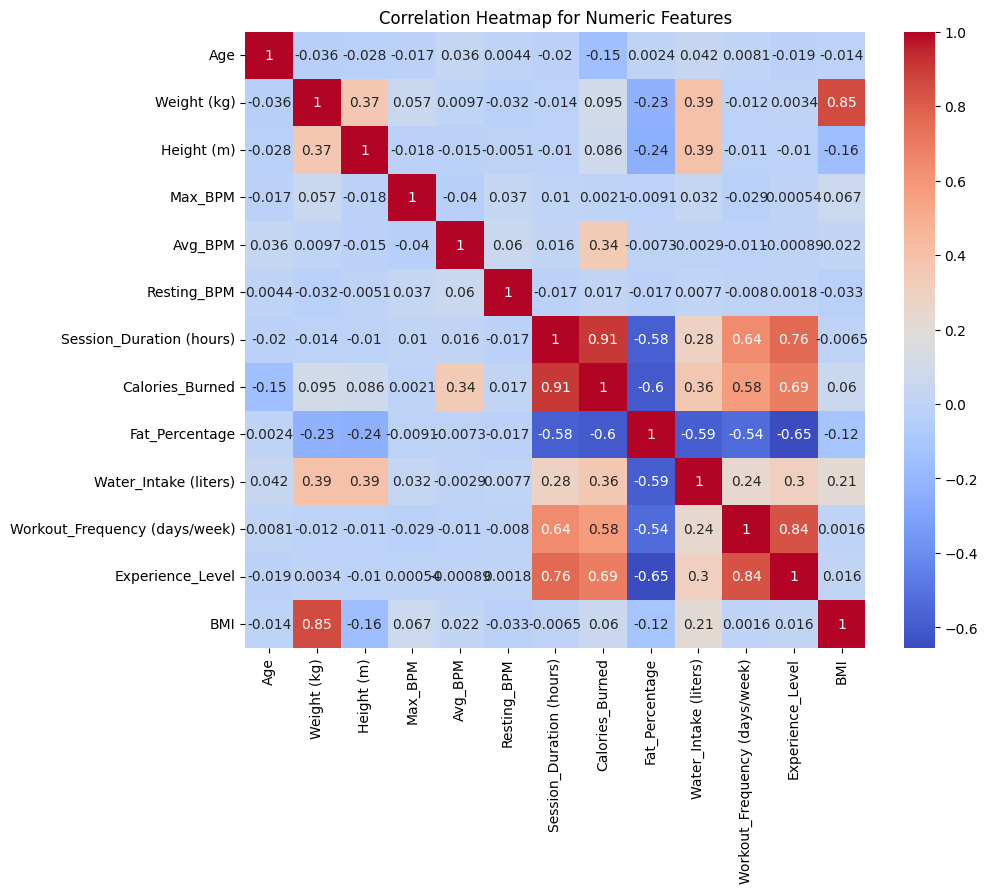

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(gym.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap for Numeric Features')

([0, 1, 2, 3],
 [Text(0, 0, 'Yoga'),
  Text(1, 0, 'HIIT'),
  Text(2, 0, 'Cardio'),
  Text(3, 0, 'Strength')])

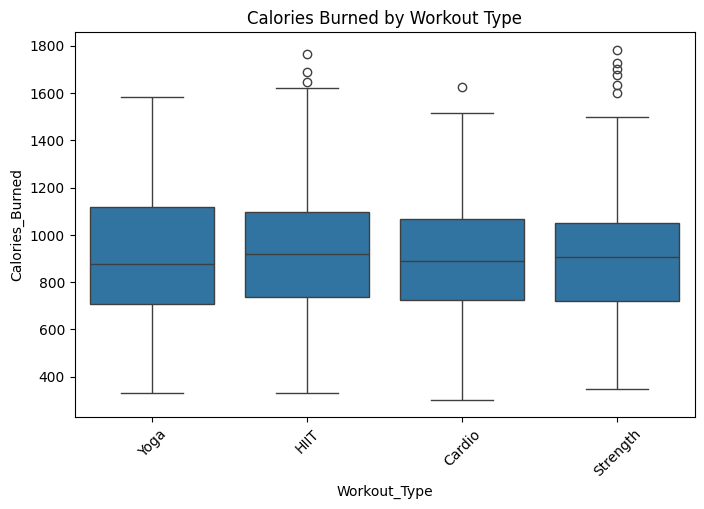

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=gym, x='Workout_Type', y='Calories_Burned')
plt.title('Calories Burned by Workout Type')
plt.xticks(rotation=45)

## Training a Linear Regression Model

Now we will train a regression model. We split the data into:

* **X**: the features used to make predictions
* **y**: the target variable, `Calories_Burned`

Because linear regression requires numeric values, we convert categorical columns such as `Gender` and `Workout_Type` into dummy variables.

### Feature Engineering

In [13]:
gym_model = pd.get_dummies(gym, columns=['Gender', 'Workout_Type'], drop_first=True)
gym_model.head()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Gender_Male,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
0,56,88.3,1.71,180,157,60,1.69,1313.0,12.6,3.5,4,3,30.20,True,False,False,True
1,46,74.9,1.53,179,151,66,1.30,883.0,33.9,2.1,4,2,32.00,False,True,False,False
2,32,68.1,1.66,167,122,54,1.11,677.0,33.4,2.3,4,2,24.71,False,False,False,False
3,25,53.2,1.70,190,164,56,0.59,532.0,28.8,2.1,3,1,18.41,True,False,True,False
4,38,46.1,1.79,188,158,68,0.64,556.0,29.2,2.8,3,1,14.39,True,False,True,False


### X and y arrays

In [14]:
X = gym_model.drop('Calories_Burned', axis=1)
y = gym_model['Calories_Burned']

In [15]:
X.head()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Gender_Male,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
0,56,88.3,1.71,180,157,60,1.69,12.6,3.5,4,3,30.20,True,False,False,True
1,46,74.9,1.53,179,151,66,1.30,33.9,2.1,4,2,32.00,False,True,False,False
2,32,68.1,1.66,167,122,54,1.11,33.4,2.3,4,2,24.71,False,False,False,False
3,25,53.2,1.70,190,164,56,0.59,28.8,2.1,3,1,18.41,True,False,True,False
4,38,46.1,1.79,188,158,68,0.64,29.2,2.8,3,1,14.39,True,False,True,False


## Train Test Split

Now let's split the data into a training set and a testing set. We train the model on the training set and then use the test set to evaluate model performance.

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=101
)

## Creating and Training the Model

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
lm = LinearRegression()

In [20]:
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Model Evaluation

Let's evaluate the model by checking the intercept and coefficients. Coefficients show the expected change in calories burned for a one-unit increase in each feature, while holding the other features fixed.

In [21]:
print('Intercept:', lm.intercept_)

Intercept: -1003.6901534938957


In [22]:
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
coeff_df.sort_values(by='Coefficient', ascending=False)

,Coefficient
Session_Duration (hours),714.998326
Height (m),99.049622
Gender_Male,84.608536
Avg_BPM,6.275943
BMI,3.305404
Resting_BPM,0.293763
Workout_Frequency (days/week),0.114908
Experience_Level,0.070275
Max_BPM,0.029333
Fat_Percentage,-0.191238


## Predictions from our Model

Let's generate predictions on the test set and compare them with the actual values.

In [23]:
predictions = lm.predict(X_test)

Text(0.5, 1.0, 'Actual vs Predicted Calories Burned')

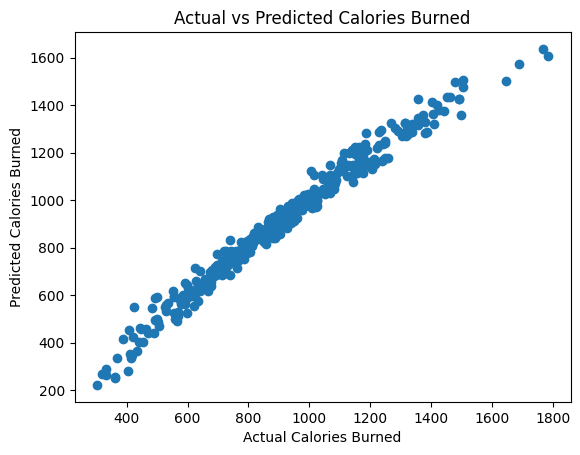

In [24]:
plt.scatter(y_test, predictions)
plt.xlabel('Actual Calories Burned')
plt.ylabel('Predicted Calories Burned')
plt.title('Actual vs Predicted Calories Burned')

**Residual Histogram**

Text(0, 0.5, 'Frequency')

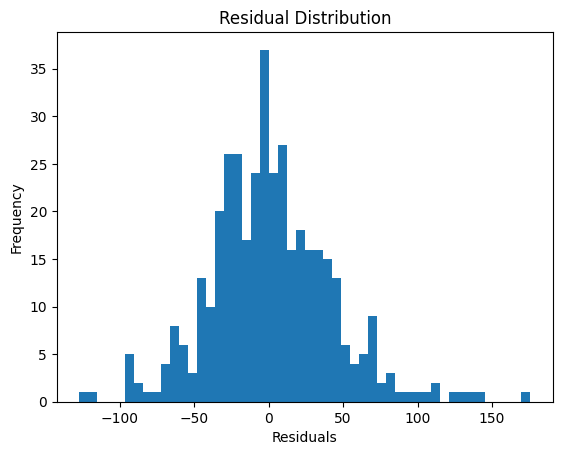

In [25]:
plt.hist((y_test - predictions), bins=50)
plt.title('Residual Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

## Regression Evaluation Metrics

Here are three common evaluation metrics for regression problems:

**Mean Absolute Error** (MAE) is the mean of the absolute value of the errors:

$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

**Mean Squared Error** (MSE) is the mean of the squared errors:

$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

**Root Mean Squared Error** (RMSE) is the square root of the mean of the squared errors:

$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

These metrics help us understand how far the model's predictions are from the actual calories burned values.

In [26]:
from sklearn import metrics

In [27]:
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('R2 Score:', metrics.r2_score(y_test, predictions))

MAE: 31.149640880478156
MSE: 1719.7154280529603
RMSE: 41.469451745266184
R2 Score: 0.9764820807915756


## Conclusion

This lab now uses the gym member exercise tracking dataset correctly. The linear regression model predicts `Calories_Burned` using numeric workout and health features, with categorical columns encoded using dummy variables.